<a href="https://colab.research.google.com/github/sebaegana/uft_mp_clases_website/blob/master/clase_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
if (!require("readxl")) install.packages("readxl")
library(readxl)
if (!require("tidyverse")) install.packages("tidyverse")
library(tidyverse)
if (!require("scales")) install.packages("scales")
library(scales)
if (!require("readr")) install.packages("readr")
library(readr)
if (!require("knitr")) install.packages("knitr")
library(knitr)
if (!require("kableExtra")) install.packages("kableExtra")
library(kableExtra)
if (!require("IRdisplay")) install.packages("IRdisplay")
library(IRdisplay)

In [43]:
# Funciones auxiliares del script
get_prices_checked <- function(from, to = Sys.Date()) {
  price_candidates <- c(
    file.path("precios_latam_ltm_sn.xlsx")
  )
  price_path <- price_candidates[file.exists(price_candidates)][1]

  if (is.na(price_path)) {
    warning("No fue posible encontrar el archivo Excel con precios de LATAM.")
    return(NULL)
  }

  precios <- tryCatch(
    read_excel(price_path, sheet = "precios"),
    error = function(e) NULL,
    warning = function(w) NULL
  )
  if (!is.data.frame(precios) || nrow(precios) == 0 || !"adjusted" %in% names(precios)) {
    warning("No fue posible leer precios validos desde el archivo Excel.")
    return(NULL)
  }

  precios %>%
    mutate(date = as.Date(date)) %>%
    filter(date >= as.Date(from), date <= as.Date(to)) %>%
    arrange(date)
}

plot_latam_prices <- function(from, to = Sys.Date(), subtitle_prefix = "Ultimo cierre") {
  precios <- get_prices_checked(from = from, to = to)
  if (is.null(precios)) {
    return(invisible(NULL))
  }

  ultimo <- precios |> dplyr::slice_tail(n = 1) |> dplyr::pull(adjusted)

  p <- ggplot(precios, aes(date, adjusted)) +
    geom_line(linewidth = 0.8) +
    labs(
      title = "LATAM Airlines Group",
      subtitle = paste0(
        subtitle_prefix, ": ",
        label_dollar(prefix = "$", big.mark = ".", decimal.mark = ",")(ultimo),
        " CLP (", max(precios$date), ")"
      ),
      x = "Fecha",
      y = "Precio ajustado (CLP)",
      caption = "Fuente: archivo local precios_latam_ltm_sn.xlsx"
    ) +
    theme_minimal()

  if (!missing(to) && !identical(to, Sys.Date())) {
    p <- p + scale_x_date(date_breaks = "3 months", date_labels = "%Y-%m")
  }

  print(p)
  invisible(precios)
}


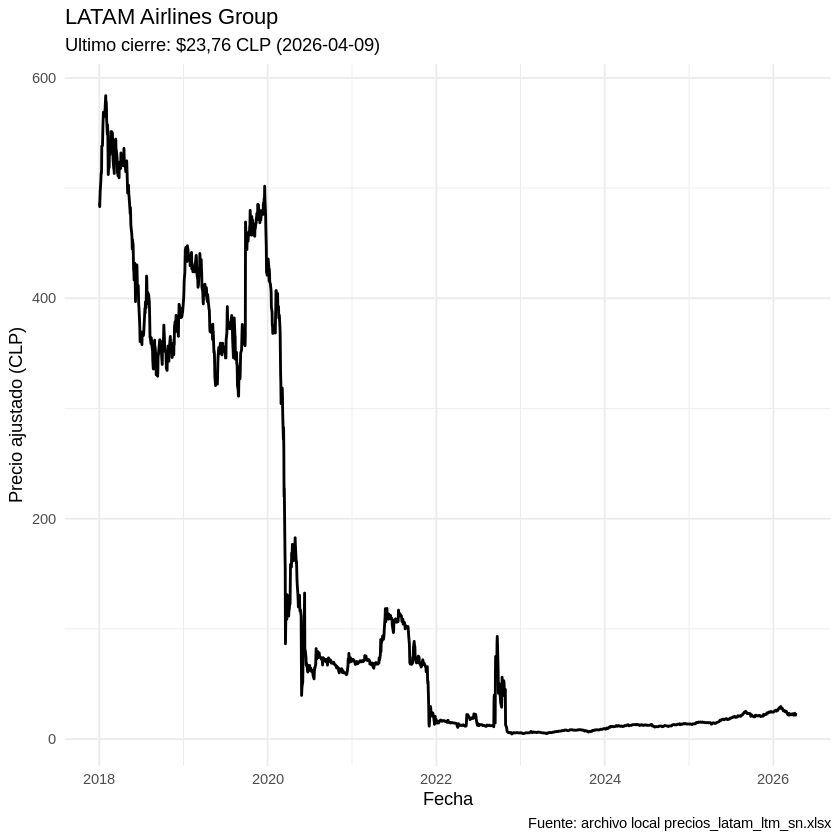

In [44]:
# Caso 1: graficos LATAM
## Gráficos LATAM
################################################################################

desde  <- "2018-01-01"
plot_latam_prices(from = desde, to = Sys.Date(), subtitle_prefix = "Ultimo cierre")

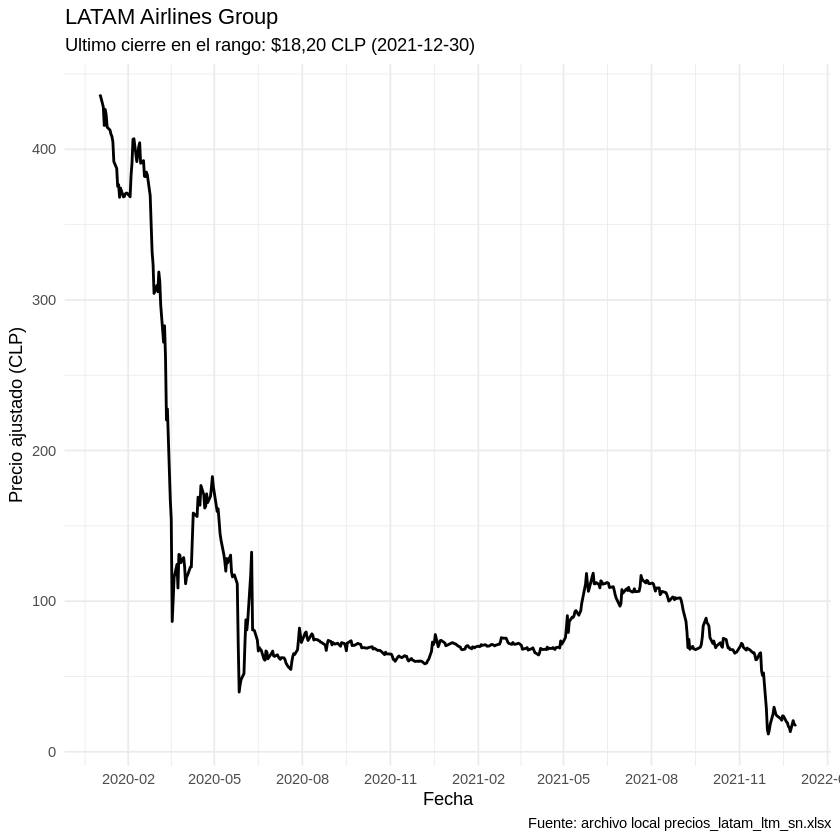

In [45]:
desde  <- "2020-01-01"
hasta  <- "2021-12-31"
plot_latam_prices(from = desde, to = hasta, subtitle_prefix = "Ultimo cierre en el rango")

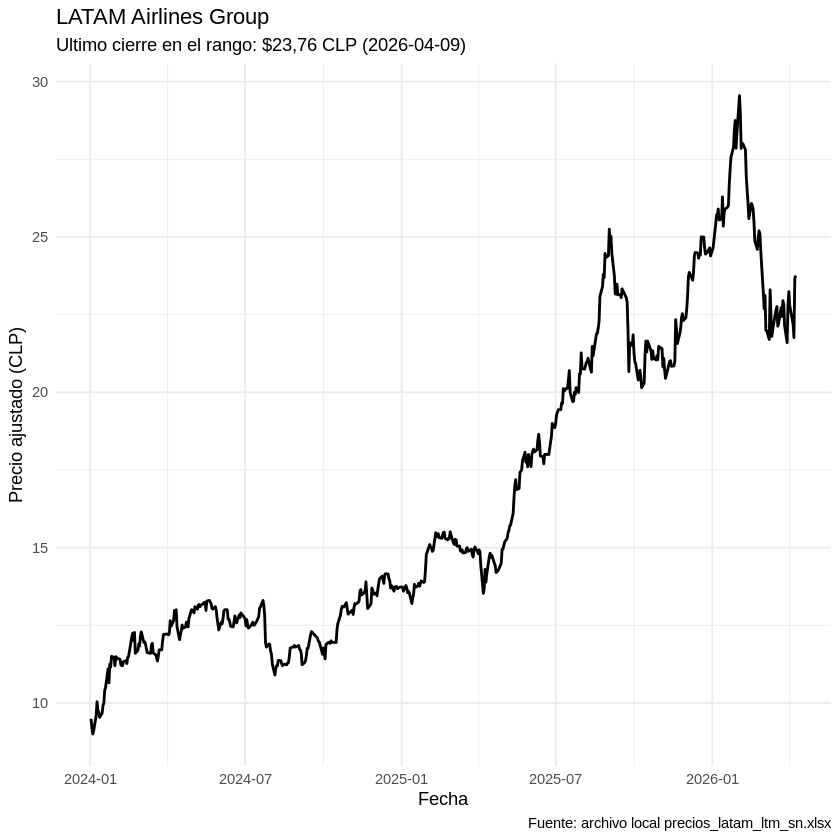

In [46]:
desde  <- "2024-01-01"
hasta  <- Sys.Date()
plot_latam_prices(from = desde, to = hasta, subtitle_prefix = "Ultimo cierre en el rango")

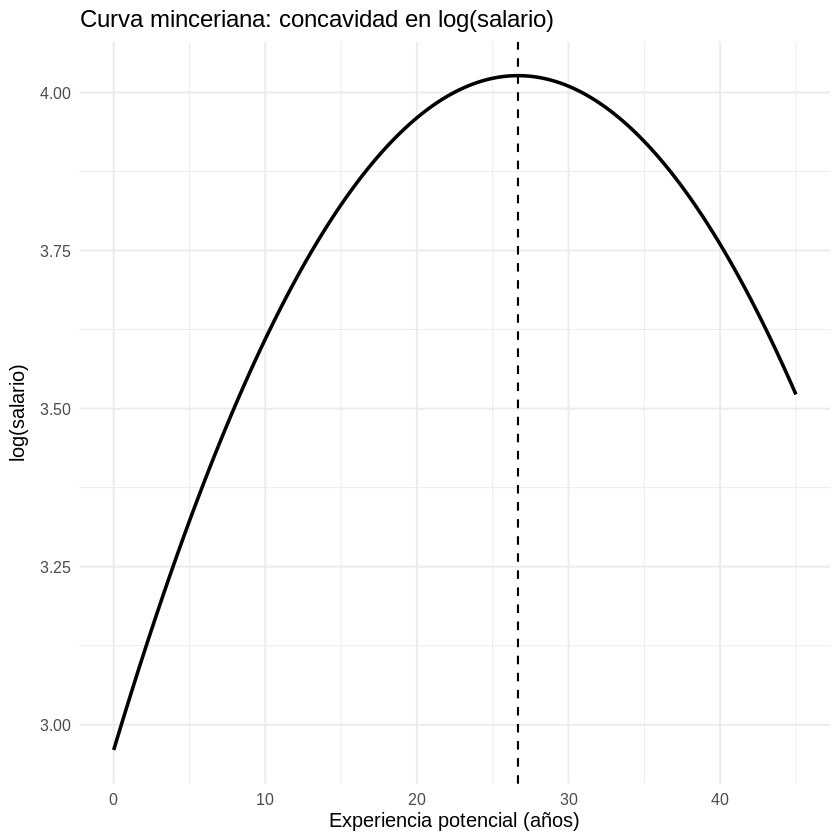

In [47]:
# Caso 2: grafico de Mincer
## Gráficos Mincer
################################################################################

# Parámetros "Mincer" (ejemplo)
beta0 <- 2.0           # intercepto
rho   <- 0.08          # retorno a la educación (no afecta la concavidad si S es fijo)
beta1 <- 0.08          # coef. experiencia > 0
beta2 <- -0.0015       # coef. experiencia^2 < 0  -> concavidad
S     <- 12            # años de escolaridad (fijo solo para desplazar el nivel)

# Rango de experiencia (0 a 45 años)
X <- seq(0, 45, by = 0.25)

# log-salario y salario (opcional) según Mincer
ln_w <- beta0 + rho*S + beta1*X + beta2*X^2
w    <- exp(ln_w)

# Vértice (máximo de ln(w))
x_star <- -beta1/(2*beta2)
y_star <- beta0 + rho*S + beta1*x_star + beta2*x_star^2

df <- data.frame(X, ln_w, w)

# Gráfico principal: concavidad en log-salario
p <- ggplot(df, aes(X, ln_w)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = x_star, linetype = 2, linewidth = 0.6) +
  labs(
    title = "Curva minceriana: concavidad en log(salario)",
    x = "Experiencia potencial (años)",
    y = "log(salario)"
  ) +
  theme_minimal(base_size = 12)

p


In [48]:
resp_candidates <- c("df_filtered_respiratorio.xlsx")
resp_path <- resp_candidates[file.exists(resp_candidates)][1]
stopifnot(!is.na(resp_path))

df_filtered <- read_excel(resp_path) %>%
  mutate(
    Anio = as.integer(Anio),
    SemanaEstadistica = as.integer(SemanaEstadistica),
    NumTotal = as.numeric(NumTotal)
  )

intro_table <- tibble(
  rows = nrow(df_filtered),
  columns = ncol(df_filtered),
  discrete_columns = sum(vapply(
    df_filtered,
    function(x) is.character(x) || is.factor(x) || is.logical(x),
    logical(1)
  )),
  continuous_columns = sum(vapply(df_filtered, is.numeric, logical(1))),
  all_missing_columns = sum(vapply(df_filtered, function(x) all(is.na(x)), logical(1))),
  total_missing_values = sum(is.na(df_filtered))
)

# Generar la tabla HTML
tabla_html <- intro_table %>%
  select(rows, columns, discrete_columns, continuous_columns,
         all_missing_columns, total_missing_values) %>%
  kable(
    format = "html",
    caption = "Resumen general del dataset"
  ) %>%
  kable_styling(
    bootstrap_options = c("striped", "hover", "condensed"),
    full_width = F,
    position = "center"
  )

# Forzar el renderizado en Colab
display_html(as.character(tabla_html))

rows,columns,discrete_columns,continuous_columns,all_missing_columns,total_missing_values
317682,25,12,13,0,23700


In [49]:
sotero_01 <-
  df_filtered %>%
  filter(RegionCodigo == 13
         & ServicioSaludCodigo == 14
         & ComunaCodigo == 13201
         & EstablecimientoGlosa == "Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)") %>%
  select(EstablecimientoGlosa, Anio, NumTotal, Causa) %>%
  filter(Causa == "TOTAL CAUSAS SISTEMA RESPIRATORIO") %>%
  group_by(EstablecimientoGlosa, Anio) %>%
  summarise(total_casos = sum(NumTotal), .groups = "drop")

# Generar la tabla HTML para visualización
tabla_sotero <- sotero_01 %>%
  kable(
    format = "html",
    caption = "Atenciones por año"
  ) %>%
  kable_styling(
    bootstrap_options = c("striped", "hover", "condensed"),
    full_width = F,
    position = "center"
  )

# Renderizar la tabla
display_html(as.character(tabla_sotero))

EstablecimientoGlosa,Anio,total_casos
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2014,17671
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2015,18090
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2016,18479
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2017,19744
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2018,18586
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2019,22210
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2020,6324
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2021,5634
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2022,19852
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2023,17479


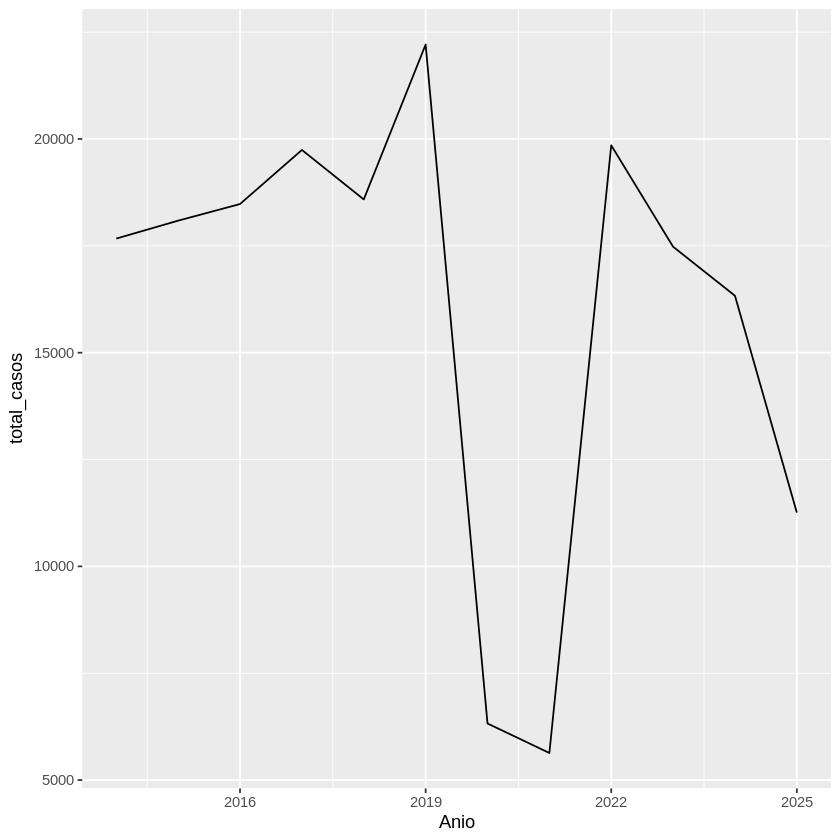

In [50]:
graph_01 <-
  ggplot(sotero_01) +
  geom_line(aes(Anio, total_casos))

graph_01


In [51]:
# Pronosticos
## Técnicas de pronósticos
################################################################################

# === Parámetros de pronóstico ===
k      <- 3      # ventana del promedio móvil
alpha  <- 0.30   # suavizamiento exponencial (0<alpha<1)

# === 1) Normalizar nombres y ordenar ===
df <- sotero_01 %>%
  rename(
    Anio       = dplyr::matches("(?i)^(anio|year)$"),
    Atenciones = dplyr::matches("(?i)^(total_casos|atenciones|valor|count)$")
  ) %>%
  arrange(Anio) %>%
  filter(Anio != 2025) %>%
  ungroup()

y <- df$Atenciones

# Chequeo mínimo
stopifnot(length(y) >= k, alpha > 0, alpha < 1)

# === 2) Pronóstico por Promedio Móvil (PM) ===
pm_forecast <- mean(tail(y, k))  # \hat{y}_{T+1} = promedio de los últimos k

# === 3) Pronóstico por Suavizamiento Exponencial Simple (SES) ===
# s_t = alpha*y_t + (1-alpha)*s_{t-1}; pronóstico \hat{y}_{T+1} = s_T
s <- y[1]
for (i in 2:length(y)) {
  s <- alpha*y[i] + (1 - alpha) * s
}
ses_forecast <- s

# === 4) Construir tabla final (agrega fila del año siguiente con pronósticos) ===
next_year <- max(df$Anio) + 1

tabla_forecasts <- df %>%
  add_row(Anio = next_year, Atenciones = NA_real_) %>%
  mutate(
    `PM(k)`        = c(rep(NA_real_, n() - 1), pm_forecast),
    `SES(alpha)`   = c(rep(NA_real_, n() - 1), ses_forecast)
  )

# Generar la tabla HTML para visualización
tabla_forecast_html <- tabla_forecasts %>%
  kable(
    format  = "html",
    caption = sprintf(
      "Atenciones por año con pronósticos: PM (k=%d) y SES (\\alpha=%.2f) para %d",
      k, alpha, next_year
    )
  ) %>%
  kable_styling(
    bootstrap_options = c("striped", "hover", "condensed"),
    full_width = F,
    position = "center"
  )

# Renderizar la tabla
display_html(as.character(tabla_forecast_html))

EstablecimientoGlosa,Anio,Atenciones,PM(k),SES(alpha)
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2014,17671,NA,NA
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2015,18090,NA,NA
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2016,18479,NA,NA
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2017,19744,NA,NA
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2018,18586,NA,NA
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2019,22210,NA,NA
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2020,6324,NA,NA
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2021,5634,NA,NA
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2022,19852,NA,NA
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",2023,17479,NA,NA


In [52]:
# Simulacion
## Simulaciones de Monte Carlo
################################################################################

set.seed(123)

# =========================
# Parámetros del ejercicio
# =========================
k      <- 3         # ventana Promedio Móvil
alpha  <- 0.30      # SES
B      <- 10000     # simulaciones
capacidad_max <- NA_real_   # pon un número si quieres calcular prob. (p.ej., 20000)

# ==============
# Preparar datos
# ==============
df <- sotero_01 %>%
  rename(
    Anio       = Anio,
    Atenciones = total_casos
  ) %>%
  filter(Anio != 2025) %>%
  arrange(Anio)


stopifnot(nrow(df) >= k + 2)

y <- df$Atenciones
Tobs <- length(y)
anio_sig <- max(df$Anio) + 1

# ===========================
# 1) Promedio Móvil (PM, k)
# ===========================
# Pronóstico puntual:
pm_hat_T1 <- mean(tail(y, k))

# Fitted one-step-ahead para residuales (a partir de t=k):
pm_fitted <- sapply(k:Tobs, function(t) mean(y[(t-k+1):t]))
pm_resid  <- y[k:Tobs] - pm_fitted

# Distribución de error por bootstrap de residuales:
pm_err_boot <- sample(pm_resid, size = B, replace = TRUE)
pm_sim_T1   <- pmax(0, pm_hat_T1 + pm_err_boot)  # truncar a 0 si aplica

# ===============================
# 2) Suavizamiento Exponencial
# ===============================
# Suavizado y fitted:
s <- y[1]
ses_fitted <- rep(NA_real_, Tobs)
ses_fitted[1] <- s
for (t in 2:Tobs) {
  s <- alpha * y[t] + (1 - alpha) * s
  ses_fitted[t] <- s
}
ses_hat_T1 <- ses_fitted[Tobs]           # pronóstico
ses_resid  <- y[-1] - ses_fitted[-Tobs]  # residuales 1-step (del 2 al T)

# Bootstrap de residuales:
ses_err_boot <- sample(ses_resid, size = B, replace = TRUE)
ses_sim_T1   <- pmax(0, ses_hat_T1 + ses_err_boot)

# =========================
# 3) Resúmenes de simulación
# =========================
qfun <- function(x) {
  qs <- quantile(x, c(0.05, 0.95), names = FALSE, na.rm = TRUE)
  tibble::tibble(
    Mediana = median(x, na.rm = TRUE),
    P5     = qs[1],
    P95    = qs[2]
  )
}

pm_summ  <- qfun(pm_sim_T1)
ses_summ <- qfun(ses_sim_T1)

prob_cap_pm  <- if (is.na(capacidad_max)) NA_real_ else mean(pm_sim_T1  >= capacidad_max)
prob_cap_ses <- if (is.na(capacidad_max)) NA_real_ else mean(ses_sim_T1 >= capacidad_max)

tabla_mc <- tibble::tibble(
  Metodo                 = c(sprintf("PM (k=%d)", k), sprintf("SES (α=%.2f)", alpha)),
  `Pronóstico puntual`   = c(pm_hat_T1, ses_hat_T1),
  `Mediana MC`           = c(pm_summ[["Mediana"]], ses_summ[["Mediana"]]),
  `P5 MC`                = c(pm_summ[["P5"]], ses_summ[["P5"]]),
  `P95 MC`               = c(pm_summ[["P95"]], ses_summ[["P95"]]),
  `Prob ≥ capacidad`     = c(prob_cap_pm, prob_cap_ses)
)

# =========================
# 4) Tabla HTML
# =========================

tabla_mc_html <- tabla_mc %>%
  kable(
    format  = "html",
    digits = 1,
    caption = sprintf(
      "Pronóstico para %d con intervalos Monte Carlo (B=%d). %s",
      anio_sig, B,
      if (is.na(capacidad_max)) "" else sprintf("Capacidad = %.0f", capacidad_max)
    )
  ) %>%
  kable_styling(
    bootstrap_options = c("striped", "hover", "condensed"),
    full_width = F,
    position = "center"
  )

display_html(as.character(tabla_mc_html))


stopifnot(exists("pm_sim_T1"), exists("ses_sim_T1"))

sims <- tibble(
  value  = c(pm_sim_T1, ses_sim_T1),
  method = factor(c(
    rep(sprintf("PM (k=%s)", if (exists("k")) k else "?"),   length(pm_sim_T1)),
    rep(sprintf("SES (α=%s)", if (exists("alpha")) alpha else "?"), length(ses_sim_T1))
  ))
)

sumstats <- sims %>%
  group_by(method) %>%
  summarise(
    median = median(value, na.rm = TRUE),
    p5     = quantile(value, 0.05, na.rm = TRUE, names = FALSE),
    p95    = quantile(value, 0.95, na.rm = TRUE, names = FALSE),
    .groups = "drop"
  )

Metodo,Pronóstico puntual,Mediana MC,P5 MC,P95 MC,Prob ≥ capacidad
PM (k=3),17887.7,18286.7,8505.0,27136.3,NA
SES (α=0.30),15825.1,16549.3,2506.2,23033.8,NA


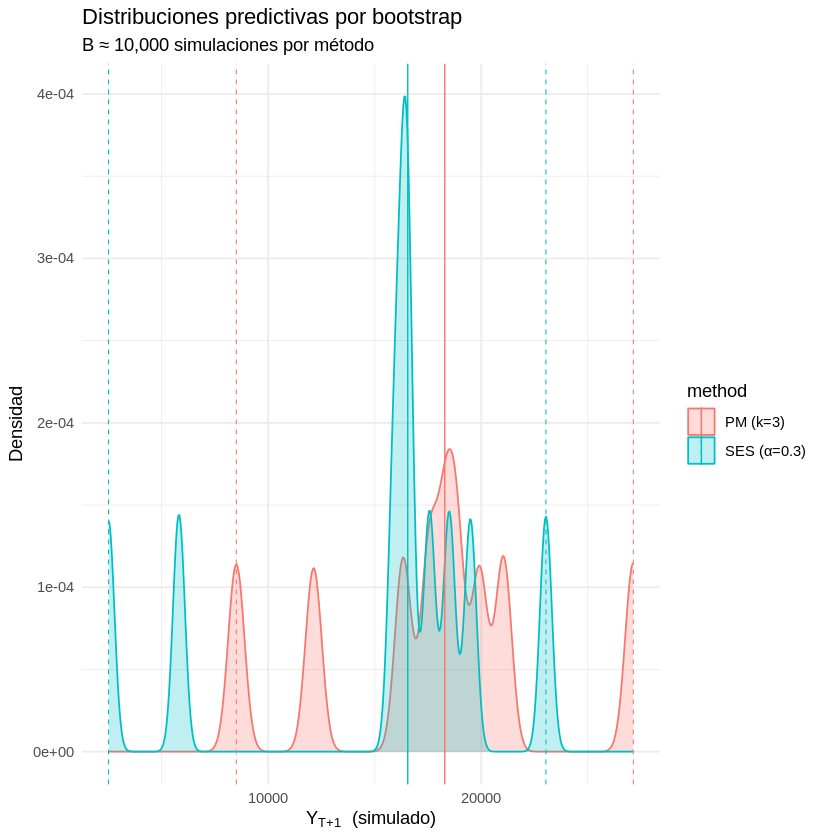

In [53]:
ggplot(sims, aes(x = value, fill = method, color = method)) +
  geom_density(alpha = 0.25, adjust = 1) +
  geom_vline(data = sumstats, aes(xintercept = median, color = method), linewidth = 0.4) +
  geom_vline(data = sumstats, aes(xintercept = p5,     color = method), linetype = "dashed", linewidth = 0.3) +
  geom_vline(data = sumstats, aes(xintercept = p95,    color = method), linetype = "dashed", linewidth = 0.3) +
  (if (exists("capacidad_max") && !is.na(capacidad_max))
    geom_vline(xintercept = capacidad_max, linetype = "dotdash", linewidth = 0.4) else NULL) +
  labs(
    x = expression(Y[T+1]~"(simulado)"),
    y = "Densidad",
    title = "Distribuciones predictivas por bootstrap",
    subtitle = sprintf("B ≈ %s simulaciones por método", format(length(pm_sim_T1), big.mark = ","))
  ) +
  theme_minimal(base_size = 11)

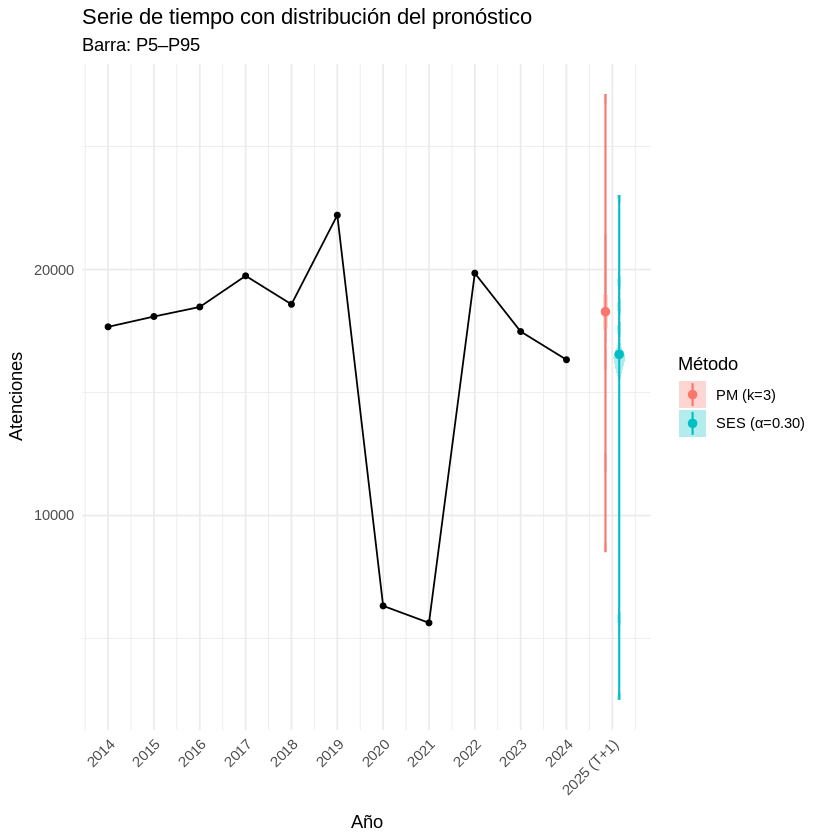

In [54]:
# --- Datos base: asume sotero_01 con año y atenciones ---
df <- sotero_01 %>%
  rename(
    Anio       = Anio,
    Atenciones = total_casos
  ) %>%
  filter(Anio != 2025) %>%
  arrange(Anio)

k     <- if (exists("k")) k else 3
alpha <- if (exists("alpha")) alpha else 0.30
B     <- if (exists("B")) B else 10000

y <- df$Atenciones
Tobs <- length(y)
next_year <- max(df$Anio) + 1

# --- Si no existen simulaciones, calcúlalas (bootstrap de residuales) ---
if (!exists("pm_sim_T1") || !exists("ses_sim_T1")) {
  # PM (k)
  pm_hat    <- mean(tail(y, k))
  pm_fitted <- sapply(k:Tobs, function(t) mean(y[(t-k+1):t]))
  pm_resid  <- y[k:Tobs] - pm_fitted
  pm_sim_T1 <- pmax(0, pm_hat + sample(pm_resid, B, replace = TRUE))

  # SES (α)
  s <- y[1]; ses_fitted <- numeric(Tobs); ses_fitted[1] <- s
  for (t in 2:Tobs) { s <- alpha*y[t] + (1-alpha)*s; ses_fitted[t] <- s }
  ses_hat    <- ses_fitted[Tobs]
  ses_resid  <- y[-1] - ses_fitted[-Tobs]
  ses_sim_T1 <- pmax(0, ses_hat + sample(ses_resid, B, replace = TRUE))
}

# --- Data frames para gráfica ---
sims <- tibble(
  value  = c(pm_sim_T1, ses_sim_T1),
  method = factor(rep(c(sprintf("PM (k=%d)", k), sprintf("SES (α=%.2f)", alpha)),
                      c(length(pm_sim_T1), length(ses_sim_T1))))
)

sumstats <- sims %>%
  group_by(method) %>%
  summarise(
    med = median(value),
    p5  = quantile(value, 0.05, names = FALSE),
    p95 = quantile(value, 0.95, names = FALSE),
    .groups = "drop"
  ) %>%
  # separar ligeramente PM y SES en el eje x para que no se monten
  mutate(x = next_year + if_else(method == levels(method)[1], -0.15, 0.15))

sims_plot <- sims %>%
  mutate(x = next_year + if_else(method == levels(method)[1], -0.15, 0.15))

# --- Plot: serie histórica + distribución futura ---
ggplot() +
  geom_line(data = df, aes(Anio, Atenciones)) +
  geom_point(data = df, aes(Anio, Atenciones), size = 1.3) +
  # distribución en T+1: violín
  geom_violin(data = sims_plot, aes(x, value, fill = method),
              width = 0.25, alpha = 0.30, color = NA) +
  # intervalo P5–P95 y mediana
  geom_linerange(data = sumstats, aes(x, ymin = p5, ymax = p95, color = method),
                 linewidth = 0.6) +
  geom_point(data = sumstats, aes(x, y = med, color = method), size = 2) +
  scale_x_continuous(breaks = c(df$Anio, next_year),
                     labels = c(df$Anio, paste0(next_year, " (T+1)")),
                     guide  = guide_axis(angle = 45)) +
  labs(
    x = "Año", y = "Atenciones",
    fill = "Método", color = "Método",
    title = "Serie de tiempo con distribución del pronóstico",
    subtitle = "Barra: P5–P95"
  ) +
  theme_minimal(base_size = 11)
